In [1]:
''' step 1 : problem statement '''
'''
    we are given 13 features and a target col , we need to find 
    if a person has a heart disease or not 
    1 - has a heart disease   0 - doesnot have a heart disease 
'''
import random
random.seed (69)

''' step 2 : data collection '''

In [2]:
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.expand_frame_repr", False)

df = pd.read_csv("../dataset/heart.csv")

display(df)             
print()
print(df.shape)
print()
display(df.columns.to_frame(index=False, name="Columns"))


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1



(1025, 14)



,Columns
0,age
1,sex
2,cp
3,trestbps
4,chol
5,fbs
6,restecg
7,thalach
8,exang
9,oldpeak


''' step 3 : Train Test Split '''

In [3]:
from sklearn.model_selection import train_test_split

df = df.drop_duplicates()
print(df.shape)

x = df.drop("target" , axis = 1)
y = df["target"]

x_train , x_test , y_train  , y_test = train_test_split(
    x , y , test_size = 0.2 ,
    random_state = 69 ,
    stratify = y
)

display(x_train.shape)
display(x_test.shape)


(302, 14)


(241, 13)

(61, 13)

''' step 4 : EDA '''

In [4]:
# display(df.info())


In [5]:
display(df.describe())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
display((df == 0).sum().to_frame("zero_counts"))

'''
age - cannot be zero
sex - can be zero (for either male or female)
cp - can be zero if u dont have any chest pain
trestbps - bp cannot be zero 
chol - cannot be zero chloestrol
fbs - blood sugar 1 if > 120 else 0 , can be zero
restecg - cna be zero 
thalach - maximum heary rate , this cannot be zero 
exang - exercise , if yes then 1 else 0 , can be zero
oldpeak - if depression then 1 else 0 , can be zero 
slope - can be zero  
ca - if blood vessels are coloured then 0 else 1 , can be zero
thal - 
'''

,zero_counts
age,0
sex,96
cp,143
trestbps,0
chol,0
fbs,257
restecg,147
thalach,0
exang,203
oldpeak,98


'\nage - cannot be zero\nsex - can be zero (for either male or female)\ncp - can be zero if u dont have any chest pain\ntrestbps - bp cannot be zero \nchol - cannot be zero chloestrol\nfbs - blood sugar 1 if > 120 else 0 , can be zero\nrestecg - cna be zero \nthalach - maximum heary rate , this cannot be zero \nexang - exercise , if yes then 1 else 0 , can be zero\noldpeak - if depression then 1 else 0 , can be zero \nslope - can be zero  \nca - if blood vessels are coloured then 0 else 1 , can be zero\nthal - \n'

In [7]:
display(df["target"].value_counts().to_frame("Count by class"))

,Count by class
target,
1,164
0,138


In [8]:
display(df.corr(numeric_only=True)[["target"]].sort_values("target",ascending=False))

,target
target,1.000000
cp,0.432080
thalach,0.419955
slope,0.343940
restecg,0.134874
fbs,-0.026826
chol,-0.081437
trestbps,-0.146269
age,-0.221476
sex,-0.283609


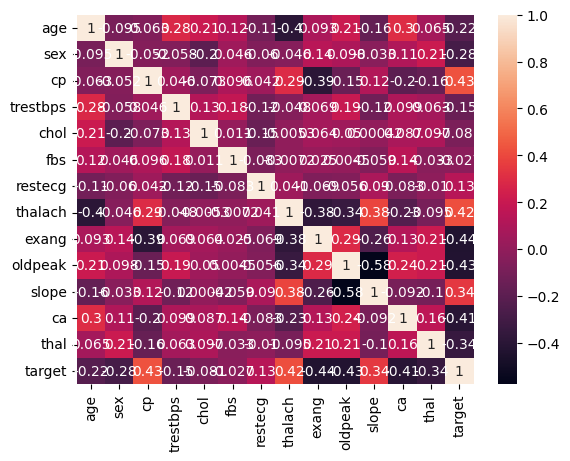

In [9]:
''' corelation visualization '''
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True)
plt.show()

''' step 5 : Preprocessing and Feature Engg '''

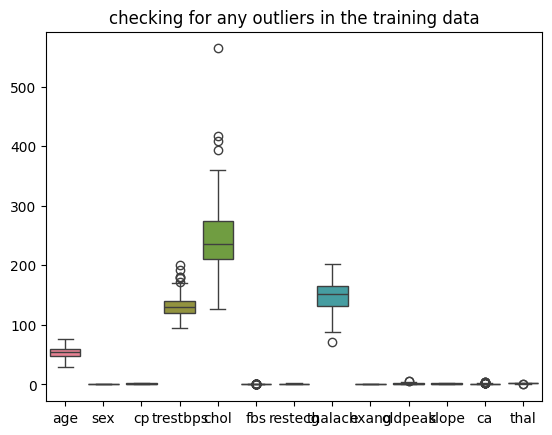

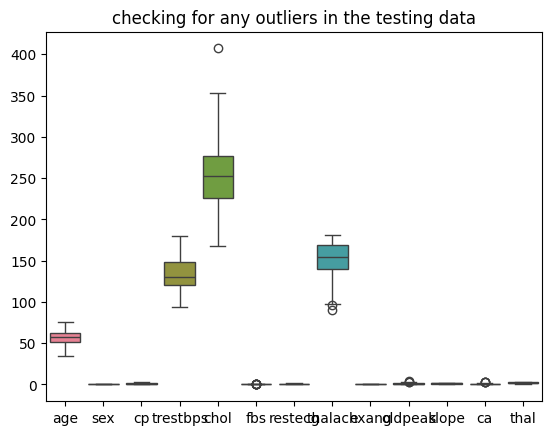

' we can see that outliers are persent '

In [10]:
''' hey dude i am not a expert in medical so hell no i aint doing any feature engg'''

'''' since we are not having any missing values we will go ahead with outlier
    finding and outlier handling 
'''

sns.boxplot(data = x_train)
plt.title("checking for any outliers in the training data")
plt.show()

sns.boxplot(data = x_test)
plt.title("checking for any outliers in the testing data")
plt.show()

''' we can see that outliers are persent '''

In [11]:
''' since outliers are present lets check how many are present in each
    feature and decide wheather we should drop it or handle the outliers 
'''
''' in short lets count the number of outliers '''

import pandas as pd 
from IPython.display import Markdown , display

def get_iqr_bounds(train_df):
    nums_cols = train_df.select_dtypes(include = "number").columns
    bounds = {}
    for col in nums_cols:
        q1 = train_df[col].quantile(0.25)
        q3 = train_df[col].quantile(0.75)
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        bounds[col] = (low,high)
    return bounds

def outlier_count_with_bounds(df,bounds):
    rows = []
    for col, (low, high) in bounds.items():
        count = ((df[col] < low) | (df[col] > high)).sum()
        rows.append([col, count, low, high])
    return pd.DataFrame(rows, columns=["Feature", "Outlier_Count", "Lower_Bound", "Upper_Bound"])

iqr_bounds = get_iqr_bounds(x_train)

train_outliers = outlier_count_with_bounds(x_train, iqr_bounds)
test_outliers  = outlier_count_with_bounds(x_test, iqr_bounds)

display(Markdown("### Training Dataset Outliers"))
display(train_outliers)

display(Markdown("### Testing Dataset Outliers"))
display(test_outliers)

''' among the outliers present we need to check '''

### Training Dataset Outliers

,Feature,Outlier_Count,Lower_Bound,Upper_Bound
0,age,0,27.5,79.5
1,sex,0,-1.5,2.5
2,cp,0,-3.0,5.0
3,trestbps,6,90.0,170.0
4,chol,4,114.0,370.0
5,fbs,37,0.0,0.0
6,restecg,0,-1.5,2.5
7,thalach,1,82.5,214.5
8,exang,0,-1.5,2.5
9,oldpeak,2,-2.7,4.5


### Testing Dataset Outliers

,Feature,Outlier_Count,Lower_Bound,Upper_Bound
0,age,0,27.5,79.5
1,sex,0,-1.5,2.5
2,cp,0,-3.0,5.0
3,trestbps,3,90.0,170.0
4,chol,1,114.0,370.0
5,fbs,8,0.0,0.0
6,restecg,0,-1.5,2.5
7,thalach,0,82.5,214.5
8,exang,0,-1.5,2.5
9,oldpeak,0,-2.7,4.5


' among the outliers present we need to check '

In [12]:
''' now lets cap the outliers '''

# capping the values
for col , (low , high) in iqr_bounds.items():
    x_train[col] = x_train[col].clip(lower = low , upper = high)
    x_test[col] = x_test[col].clip(lower = low , upper = high)

# now lets check the number of outliers again
train_outliers_atfer_handling = outlier_count_with_bounds(x_train , iqr_bounds)
test_outliers_atfer_handling = outlier_count_with_bounds(x_test , iqr_bounds)

# now lets print them 
display(Markdown("### training dataset outliers after outliers handling "))
display(train_outliers_atfer_handling)

display(Markdown("### testing dataset outliers after outliers handling "))
display(test_outliers_atfer_handling)

### training dataset outliers after outliers handling 

,Feature,Outlier_Count,Lower_Bound,Upper_Bound
0,age,0,27.5,79.5
1,sex,0,-1.5,2.5
2,cp,0,-3.0,5.0
3,trestbps,0,90.0,170.0
4,chol,0,114.0,370.0
5,fbs,0,0.0,0.0
6,restecg,0,-1.5,2.5
7,thalach,0,82.5,214.5
8,exang,0,-1.5,2.5
9,oldpeak,0,-2.7,4.5


### testing dataset outliers after outliers handling 

,Feature,Outlier_Count,Lower_Bound,Upper_Bound
0,age,0,27.5,79.5
1,sex,0,-1.5,2.5
2,cp,0,-3.0,5.0
3,trestbps,0,90.0,170.0
4,chol,0,114.0,370.0
5,fbs,0,0.0,0.0
6,restecg,0,-1.5,2.5
7,thalach,0,82.5,214.5
8,exang,0,-1.5,2.5
9,oldpeak,0,-2.7,4.5


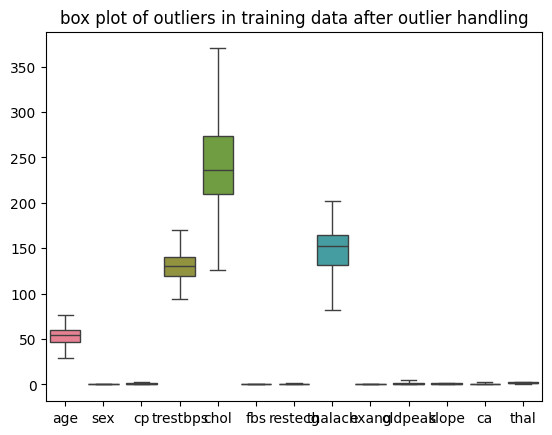

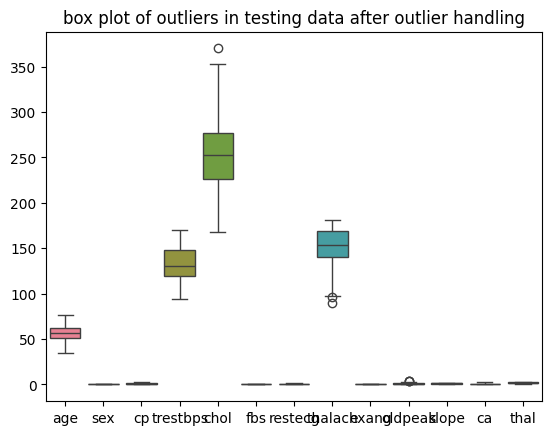

In [13]:
''' lets see with box plot if any outliers exsist '''

''' remember there may be a few outliers present in the testing dataset becasue we are 
using iqr bounds of training only to clip the test data , we are not using test iqr 
bounds so there be some outliers left in testing dataset '''

''' why are we doing this ? to avoid data_leakage'''

import seaborn as sns 

sns.boxplot(data = x_train)
plt.title("box plot of outliers in training data after outlier handling")
plt.show()

sns.boxplot(data = x_test)
plt.title("box plot of outliers in testing data after outlier handling")
plt.show()

In [14]:
''' STANDARDIZATION '''

from sklearn.preprocessing import MinMaxScaler , StandardScaler

scaler = StandardScaler()

# fit and transform the training data so that it learns the parameters to scale both training and 
# testing data 
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# renaming them back to origninal names for no confusion and converting them back to df 
# why convert them back ? because scaler outputs the numpy array not dataframe 
x_train = pd.DataFrame(x_train_scaled, columns = x_train.columns , index = x_train.index)
x_test = pd.DataFrame(x_test_scaled, columns = x_test.columns , index = x_test.index)

# lets display them 
display(Markdown("### training ds after scaling"))
display(x_train.head(10))

display(Markdown("### testing ds after scaling"))
display(x_test.head(10))

### training ds after scaling

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
41,0.000459,0.672166,0.955447,-0.666511,0.320846,0.0,-0.989884,-0.109204,-0.691757,-0.605760,-0.628605,-0.763601,1.141709
270,-1.215181,0.672166,-0.955447,-1.286462,-0.678390,0.0,0.918612,0.506426,-0.691757,-0.956483,1.018067,-0.763601,1.141709
189,1.105585,0.672166,0.955447,-0.356536,1.405122,0.0,0.918612,-0.812782,1.445595,0.621768,-0.628605,-0.763601,1.141709
30,-1.104668,0.672166,-0.955447,-0.666511,-1.571324,0.0,0.918612,-0.241125,1.445595,1.498575,-2.275278,-0.763601,-2.153522
147,-1.436206,0.672166,-0.955447,-1.286462,-1.507543,0.0,-0.989884,0.374506,-0.691757,-0.956483,1.018067,-0.763601,1.141709
498,0.000459,0.672166,-0.955447,0.573390,-0.083101,0.0,0.918612,0.462453,-0.691757,0.095685,1.018067,-0.763601,-0.505907
58,1.437123,0.672166,0.955447,1.317331,-0.657129,0.0,-0.989884,0.022717,-0.691757,-0.255038,-0.628605,-0.763601,1.141709
322,-0.994155,0.672166,-0.955447,0.697380,1.405122,0.0,-0.989884,-0.109204,1.445595,-0.956483,-0.628605,2.041700,1.141709
536,-0.441592,-1.487728,0.955447,-0.666511,-0.508307,0.0,0.918612,0.374506,-0.691757,0.446407,-0.628605,-0.763601,-0.505907
733,-1.104668,-1.487728,0.955447,-1.410452,-2.166613,0.0,0.918612,1.122057,-0.691757,-0.430399,-0.628605,-0.763601,-0.505907


### testing ds after scaling

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
281,-2.099282,0.672166,0.000000,-0.542521,-1.082336,0.0,0.918612,1.078083,-0.691757,-0.956483,1.018067,-0.763601,-0.505907
402,1.768661,0.672166,0.000000,1.565311,0.044461,0.0,-0.989884,-0.285099,-0.691757,-0.956483,1.018067,-0.763601,-0.505907
11,-1.215181,-1.487728,-0.955447,0.077430,2.085453,0.0,-0.989884,-0.592914,1.445595,1.673936,-0.628605,-0.763601,1.141709
299,-0.220567,0.672166,0.000000,-0.666511,1.745288,0.0,0.918612,0.990136,-0.691757,-0.781122,1.018067,-0.763601,-0.505907
297,0.442509,0.672166,-0.955447,1.193341,0.575970,0.0,-0.989884,-1.692254,1.445595,-0.255038,1.018067,-0.763601,1.141709
148,-0.220567,0.672166,1.910894,1.317331,1.171259,0.0,0.918612,1.253978,-0.691757,0.095685,-0.628605,-0.763601,1.141709
126,1.326610,0.672166,-0.955447,-0.666511,1.256300,0.0,-0.989884,0.066690,-0.691757,-0.605760,-0.628605,-0.763601,-0.505907
74,-0.662617,0.672166,-0.955447,-0.046561,0.278325,0.0,-0.989884,0.022717,1.445595,-0.956483,1.018067,1.480640,1.141709
131,-0.331079,-1.487728,0.955447,-0.046561,0.278325,0.0,-0.989884,-0.021257,-0.691757,-0.518080,1.018067,-0.763601,-0.505907
57,-0.662617,0.672166,0.000000,-0.046561,0.044461,0.0,-0.989884,1.341925,-0.691757,-0.781122,-0.628605,-0.763601,-0.505907


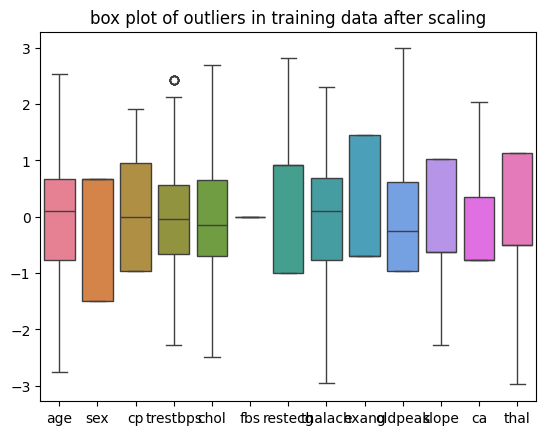

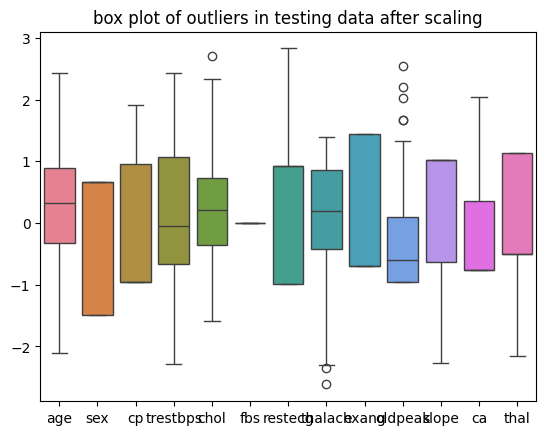

In [15]:
''' this is not cumpulsory '''
''' lets see the outliers in the data after scaling : remember there will be some outliers in 
the data because after scaling there will be new iqr bounds and some data may not satisfy those 
bounds'''


import seaborn as sns 

sns.boxplot(data = x_train)
plt.title("box plot of outliers in training data after scaling")
plt.show()

sns.boxplot(data = x_test)
plt.title("box plot of outliers in testing data after scaling")
plt.show()

''' step 6 : baseline model selection  '''

In [16]:
''' let us divide our training dataset into validation and training'''

from sklearn.model_selection import train_test_split

x_tr_bms , x_val_bms , y_tr_bms , y_val_bms = train_test_split(
    x_train , y_train , 
    test_size = 0.2 , 
    random_state = 69 ,
    stratify = y_train
)

# lets see the training and validation dataset

display(Markdown("### training ds after second tts"))
display(x_tr_bms.head())

display(Markdown("### validation ds after second tts"))
display(x_val_bms.head())

### training ds after second tts

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
30,-1.104668,0.672166,-0.955447,-0.666511,-1.571324,0.0,0.918612,-0.241125,1.445595,1.498575,-2.275278,-0.763601,-2.153522
358,0.553022,0.672166,1.910894,0.201420,-0.827212,0.0,0.918612,0.550400,-0.691757,-0.255038,1.018067,1.480640,-0.505907
694,-1.657231,0.672166,-0.955447,-0.790502,-0.508307,0.0,0.918612,-0.417019,-0.691757,0.095685,-0.628605,-0.763601,1.141709
723,1.547636,-1.487728,0.955447,-0.666511,-0.678390,0.0,-0.989884,-1.516360,-0.691757,0.358727,-0.628605,-0.763601,-0.505907
606,1.326610,0.672166,-0.955447,-1.162472,-0.657129,0.0,-0.989884,-0.768808,1.445595,-0.868802,1.018067,0.358520,-0.505907


### validation ds after second tts

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
232,0.663534,0.672166,-0.955447,-0.356536,0.320846,0.0,-0.989884,-0.373046,1.445595,1.498575,-0.628605,0.358520,1.141709
267,1.437123,0.672166,-0.955447,-0.666511,-0.125621,0.0,0.918612,-2.945502,-0.691757,-0.079677,-0.628605,-0.763601,-0.505907
205,-1.325693,0.672166,1.910894,1.069351,0.023201,0.0,-0.989884,1.253978,-0.691757,-0.255038,1.018067,1.480640,-0.505907
382,0.553022,0.672166,-0.955447,-1.286462,-0.083101,0.0,-0.989884,-0.329072,1.445595,0.095685,-0.628605,0.358520,1.141709
384,-2.099282,0.672166,-0.955447,-0.294541,0.831094,0.0,-0.989884,0.286558,1.445595,-0.956483,1.018067,-0.763601,1.141709


''' since the class imbalance is ~2% we dont need to do smote here '''

''' lets start hit and trail'''


In [17]:
''' baseline_model_1 : logistic regression '''
''''why ? its best for binary classfication '''

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , roc_auc_score
from sklearn.metrics import confusion_matrix , classification_report

''' model training '''

lr = LogisticRegression(
    max_iter = 1000 ,
    random_state = 69 
)
lr.fit(x_tr_bms , y_tr_bms)

''' now the model is trained and its name is lr'''

# now lets predict the outcomes
y_val_prob_lr = lr.predict_proba(x_val_bms)[:,1]
threshold = 0.5
y_val_pred_lr = (y_val_prob_lr >= threshold).astype(int)

''' metrcis '''

print("Logistic regression")
print("Accuracy :", round(accuracy_score(y_val_bms, y_val_pred_lr), 4))
print("Precision:", round(precision_score(y_val_bms, y_val_pred_lr), 4))
print("Recall   :", round(recall_score(y_val_bms, y_val_pred_lr), 4))
print("F1-score :", round(f1_score(y_val_bms, y_val_pred_lr), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val_bms, y_val_prob_lr), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_bms, y_val_pred_lr))

print("\nClassification Report:")
print(classification_report(y_val_bms, y_val_pred_lr))



Logistic regression
Accuracy : 0.8571
Precision: 0.8333
Recall   : 0.9259
F1-score : 0.8772
ROC-AUC  : 0.9192

Confusion Matrix:
[[17  5]
 [ 2 25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.77      0.83        22
           1       0.83      0.93      0.88        27

    accuracy                           0.86        49
   macro avg       0.86      0.85      0.85        49
weighted avg       0.86      0.86      0.86        49



In [18]:
''' baseline_model_2 : desicion tree'''

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , roc_auc_score
from sklearn.metrics import confusion_matrix , classification_report

'''model training'''

dt = DecisionTreeClassifier(
    random_state = 69 
)
dt.fit(x_tr_bms , y_tr_bms)

'''prediction'''

y_val_pred_dt = dt.predict(x_val_bms)
y_val_prob_dt = dt.predict_proba(x_val_bms)[:, 1]

'''metrics '''

print("decisionTreeClassifier")
print("Accuracy :", round(accuracy_score(y_val_bms, y_val_pred_dt), 4))
print("Precision :", round(precision_score(y_val_bms, y_val_pred_dt), 4))
print("Recall   :", round(recall_score(y_val_bms, y_val_pred_dt), 4))
print("F1-score :", round(f1_score(y_val_bms, y_val_pred_dt), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val_bms, y_val_prob_dt), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_bms, y_val_pred_dt))

print("\nClassification Report:")
print(classification_report(y_val_bms, y_val_pred_dt))


decisionTreeClassifier
Accuracy : 0.7755
Precision : 0.7857
Recall   : 0.8148
F1-score : 0.8
ROC-AUC  : 0.771

Confusion Matrix:
[[16  6]
 [ 5 22]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.73      0.74        22
           1       0.79      0.81      0.80        27

    accuracy                           0.78        49
   macro avg       0.77      0.77      0.77        49
weighted avg       0.78      0.78      0.77        49



In [19]:
''' baseline_model_3 : random forest '''

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

'''model training'''

rf = RandomForestClassifier(
    random_state = 69 
)
rf.fit(x_tr_bms , y_tr_bms)

''' predict '''

y_val_pred_rf = rf.predict(x_val_bms)
y_val_prob_rf = rf.predict_proba(x_val_bms)[:, 1]

'''metrics'''

print("RandomForestClassifier")
print("Accuracy :", round(accuracy_score(y_val_bms, y_val_pred_rf), 4))
print("Precision:", round(precision_score(y_val_bms, y_val_pred_rf), 4))
print("Recall   :", round(recall_score(y_val_bms, y_val_pred_rf), 4))
print("F1-score :", round(f1_score(y_val_bms, y_val_pred_rf), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val_bms, y_val_prob_rf), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_bms, y_val_pred_rf))

print("\nClassification Report:")
print(classification_report(y_val_bms, y_val_pred_rf))


RandomForestClassifier
Accuracy : 0.7755
Precision: 0.7667
Recall   : 0.8519
F1-score : 0.807
ROC-AUC  : 0.8897

Confusion Matrix:
[[15  7]
 [ 4 23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.68      0.73        22
           1       0.77      0.85      0.81        27

    accuracy                           0.78        49
   macro avg       0.78      0.77      0.77        49
weighted avg       0.78      0.78      0.77        49



In [20]:
'''baseline_model_4 : xgboost'''

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

''' model training'''

xgb = XGBClassifier(
    random_state=69,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss"
)
xgb.fit(x_tr_bms, y_tr_bms)

''' prediction '''

y_val_pred_xgb = xgb.predict(x_val_bms)
y_val_prob_xgb = xgb.predict_proba(x_val_bms)[:, 1]

''''metrics'''

print("XGBoostClassifier")
print("Accuracy :", round(accuracy_score(y_val_bms, y_val_pred_xgb), 4))
print("Precision:", round(precision_score(y_val_bms, y_val_pred_xgb), 4))
print("Recall   :", round(recall_score(y_val_bms, y_val_pred_xgb), 4))
print("F1-score :", round(f1_score(y_val_bms, y_val_pred_xgb), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val_bms, y_val_prob_xgb), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_bms, y_val_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_val_bms, y_val_pred_xgb))


XGBoostClassifier
Accuracy : 0.7959
Precision: 0.7931
Recall   : 0.8519
F1-score : 0.8214
ROC-AUC  : 0.867

Confusion Matrix:
[[16  6]
 [ 4 23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.73      0.76        22
           1       0.79      0.85      0.82        27

    accuracy                           0.80        49
   macro avg       0.80      0.79      0.79        49
weighted avg       0.80      0.80      0.79        49



In [21]:
''' baseline_model_5 : KNN '''

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report


''' model training'''

knn = KNeighborsClassifier(
    # random_state=69, # look like knn doesnot like random_state
    n_neighbors=3
)
knn.fit(x_tr_bms, y_tr_bms)

''' prediction '''

y_val_pred_knn = knn.predict(x_val_bms)
y_val_prob_knn = knn.predict_proba(x_val_bms)[:, 1]

''''metrics'''

print("KNN classifier")
print("Accuracy :", round(accuracy_score(y_val_bms, y_val_pred_knn), 4))
print("Precision:", round(precision_score(y_val_bms, y_val_pred_knn), 4))
print("Recall   :", round(recall_score(y_val_bms, y_val_pred_knn), 4))
print("F1-score :", round(f1_score(y_val_bms, y_val_pred_knn), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val_bms, y_val_prob_knn), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_bms, y_val_pred_knn))

print("\nClassification Report:")
print(classification_report(y_val_bms, y_val_pred_knn))

KNN classifier
Accuracy : 0.8367
Precision: 0.8519
Recall   : 0.8519
F1-score : 0.8519
ROC-AUC  : 0.9226

Confusion Matrix:
[[18  4]
 [ 4 23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        22
           1       0.85      0.85      0.85        27

    accuracy                           0.84        49
   macro avg       0.84      0.84      0.84        49
weighted avg       0.84      0.84      0.84        49



''' step 7 : k fold cv  and hyper parameter tuning '''


In [22]:
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold , GridSearchCV

# create a each pipeline for each k fold 
pipe = Pipeline([
    ("lr", LogisticRegression(max_iter=2000, random_state=69))
])

# the below are all the hyperparameters we need to check
param_grid = { 
    "lr__C": [0.01, 0.1,0.9,0.8, 1,2],
    "lr__solver": ["lbfgs", "liblinear"],
    "lr__class_weight": [None, "balanced"],
    "lr__max_iter": [1000, 2000, 3000]
}

# defining the k fold , shuffle means to take a new permutation everytime
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)

#saying the model to focus more on recall than on accuracy 
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="recall",   
    cv=cv,
    n_jobs=-1
)

grid.fit(x_train,y_train)
print("Best Params:", grid.best_params_)
print("Best CV recall:", round(grid.best_score_, 4))
best_model = grid.best_estimator_

Best Params: {'lr__C': 0.9, 'lr__class_weight': None, 'lr__max_iter': 1000, 'lr__solver': 'lbfgs'}
Best CV recall: 0.9234


''' step 8 : final training '''

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

''' train the best model with the best hyperparamters on the full 
training dataset'''

best_model.fit(x_train,y_train)


,steps,"[('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.9
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1


''' step 9 : final testing and getting out the metircs '''

In [24]:
''' testing on the final testing data'''

y_test_pred= best_model.predict(x_test)
y_test_prob = best_model.predict_proba(x_test)[:, 1]

'''printing out the metrics '''

print("Final Test Metrics for fine tuted logistic regression")
print("Accuracy :", round(accuracy_score(y_test, y_test_pred), 4))
print("Precision:", round(precision_score(y_test, y_test_pred), 4))
print("Recall   :", round(recall_score(y_test, y_test_pred), 4))
print("F1-score :", round(f1_score(y_test, y_test_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_test_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


Final Test Metrics for fine tuted logistic regression
Accuracy : 0.8361
Precision: 0.8286
Recall   : 0.8788
F1-score : 0.8529
ROC-AUC  : 0.9156

Confusion Matrix:
[[22  6]
 [ 4 29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.79      0.81        28
           1       0.83      0.88      0.85        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61

